<a href="https://colab.research.google.com/github/vivekanandainduri-nv/NV/blob/main/Exp4%2018-AUG-26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving WineQT.csv to WineQT.csv


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy import stats

In [ ]:
df = pd.read_csv("WineQT.csv")

In [ ]:
print(df.head(3))
print(df.tail(3))

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   

   alcohol  quality  Id  
0      9.4        5   0  
1      9.8        5   1  
2      9.8        5   2  
      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
1140            6.2             0.600         0.08             2.0      0.090   
1141            5.9             0.550         0.10             2.2      0.062   
1142            5.9             0.645      

In [ ]:
print(df.dtypes)

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
Id                        int64
dtype: object


In [17]:
print(df.describe())
pd.isna(df).any()

       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1143.000000       1143.000000  1143.000000     1143.000000   
mean        8.311111          0.531339     0.268364        2.532152   
std         1.747595          0.179633     0.196686        1.355917   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.392500     0.090000        1.900000   
50%         7.900000          0.520000     0.250000        2.200000   
75%         9.100000          0.640000     0.420000        2.600000   
max        15.900000          1.580000     1.000000       15.500000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  1143.000000          1143.000000           1143.000000  1143.000000   
mean      0.086933            15.615486             45.914698     0.996730   
std       0.047267            10.250486             32.782130     0.001925   
min       0.012000             1.000000         

,0
fixed acidity,False
volatile acidity,False
citric acid,False
residual sugar,False
chlorides,False
free sulfur dioxide,False
total sulfur dioxide,False
density,False
pH,False
sulphates,False


In [10]:
df['residual sugar'].astype(str).str.isnumeric().value_counts()

,count
residual sugar,
False,1143


In [11]:
df['residual sugar'].loc[df['residual sugar'].astype(str).str.isnumeric() == False]

,residual sugar
0,1.9
1,2.6
2,2.3
3,1.9
4,1.9
...,...
1138,2.3
1139,1.9
1140,2.0
1141,2.2


In [12]:
residual_sugar = df['residual sugar'].loc[df['residual sugar'] != '?']
print(residual_sugar)


0       1.9
1       2.6
2       2.3
3       1.9
4       1.9
       ... 
1138    2.3
1139    1.9
1140    2.0
1141    2.2
1142    2.0
Name: residual sugar, Length: 1143, dtype: float64


In [13]:
smean = residual_sugar.astype(float).mean()
print("Mean =", smean)

Mean = 2.5321522309711284


In [14]:
df['residual sugar'] = df['residual sugar'].replace('?', smean).astype(float)
print(df['residual sugar'].head(10))

0    1.9
1    2.6
2    2.3
3    1.9
4    1.9
5    1.8
6    1.6
7    1.2
8    2.0
9    1.8
Name: residual sugar, dtype: float64


In [15]:
free_so2 = df['free sulfur dioxide'].loc[df['free sulfur dioxide'] != '?']
so2mean = free_so2.astype(float).mean()
df['free sulfur dioxide'] = df['free sulfur dioxide'].replace('?', so2mean).astype(float)
print(df['free sulfur dioxide'].head())

0    11.0
1    25.0
2    15.0
3    17.0
4    11.0
Name: free sulfur dioxide, dtype: float64


In [16]:
df[df['alcohol'] == '?'].count()

al_count = df['alcohol'].loc[df['alcohol'] != '?'].count()
al_mean = df['alcohol'].loc[df['alcohol'] != '?'].astype(float).mean()

df['alcohol'] = df['alcohol'].replace('?', al_mean).astype(float)
print(df['alcohol'].head())

0    9.4
1    9.8
2    9.8
3    9.8
4    9.4
Name: alcohol, dtype: float64


In [19]:
df[df['alcohol']>=12].count()
al = df['alcohol'].loc[df['alcohol']!="12"]
almean=al.astype(float).mean()
df['alcohol']=df['alcohol'].replace('12',almean).astype(float)
print(df['alcohol'].head())

0    9.4
1    9.8
2    9.8
3    9.8
4    9.4
Name: alcohol, dtype: float64


In [20]:
mean = df['alcohol'].mean()
print(mean)
median=df['alcohol'].median()
print(median)
mode=df['alcohol'].mode()
print(mode)

10.442111402741325
10.2
0    9.5
Name: alcohol, dtype: float64


/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  func(*plot_args, **plot_kwargs)


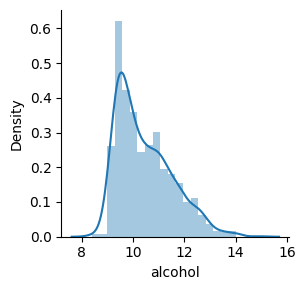

In [21]:
sns.FacetGrid(df).map(sns.distplot,"alcohol").add_legend()

<function matplotlib.pyplot.show(close=None, block=None)>

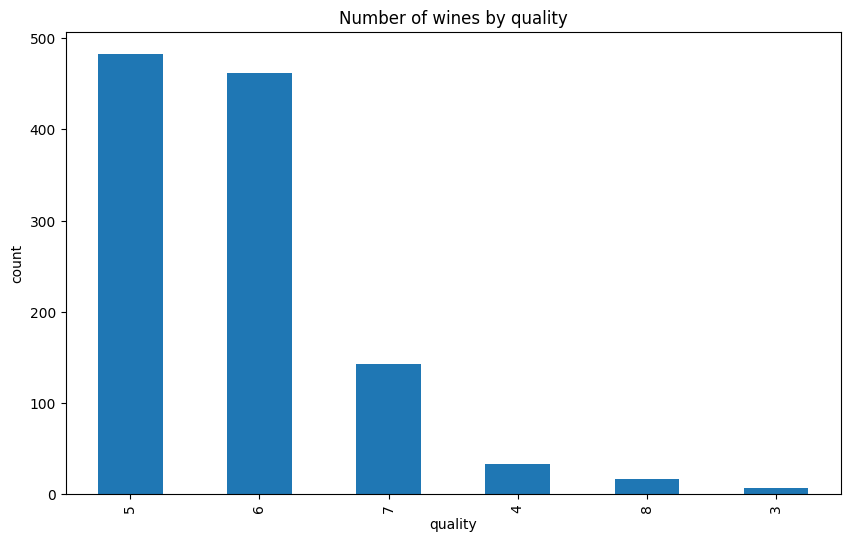

In [23]:
df['quality'].value_counts().nlargest(30).plot(kind='bar', figsize=(10,6))
plt.title("Number of wines by quality")
plt.ylabel('count')
plt.xlabel('quality')
plt.show


/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  func(*plot_args, **plot_kwargs)


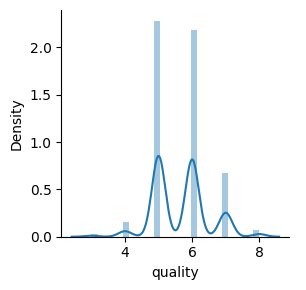

In [24]:
sns.FacetGrid(df).map(sns.distplot,"quality").add_legend()

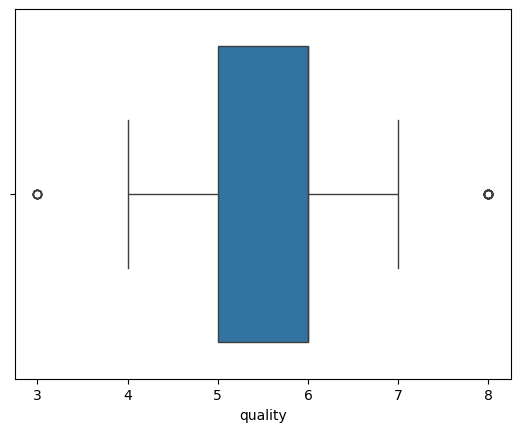

In [25]:
sns.boxplot(x="quality",data=df)
plt.show()

Text(0, 0.5, 'quality')

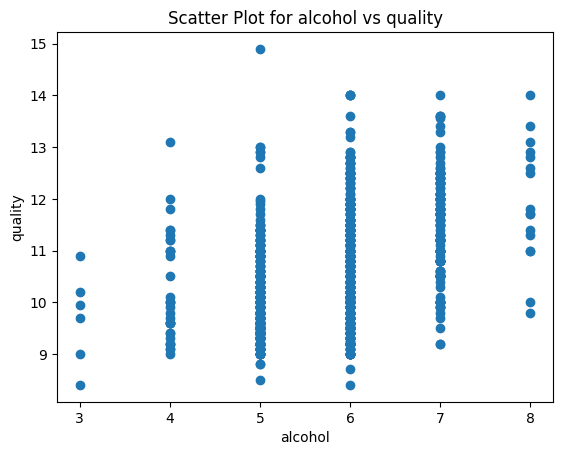

In [26]:
plt.scatter(df["quality"], df["alcohol"])
plt.title("Scatter Plot for alcohol vs quality")
plt.xlabel("alcohol")
plt.ylabel("quality")

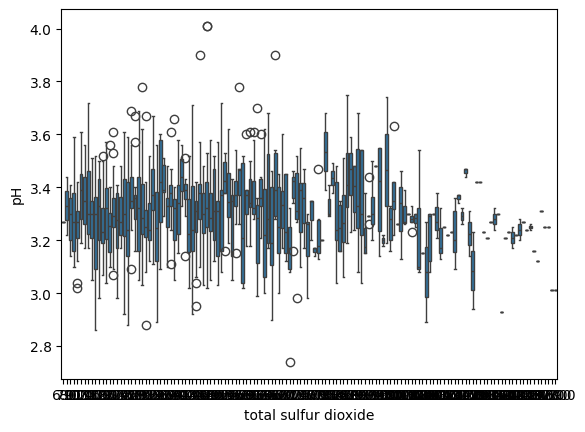

In [27]:
sns.boxplot(x="total sulfur dioxide",y="pH",data=df)
plt.show()

<Axes: xlabel='citric acid', ylabel='pH'>

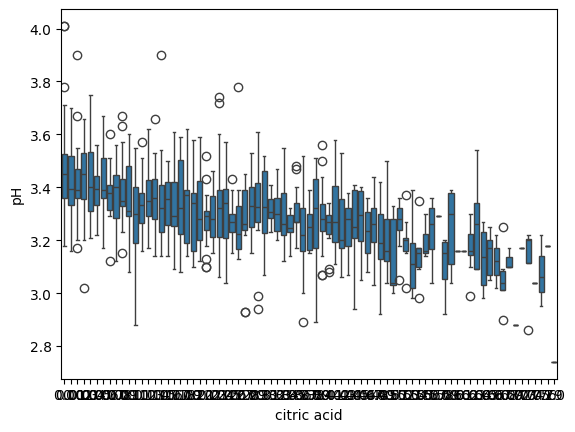

In [28]:
sns.boxplot(x="citric acid", y="pH",data=df)

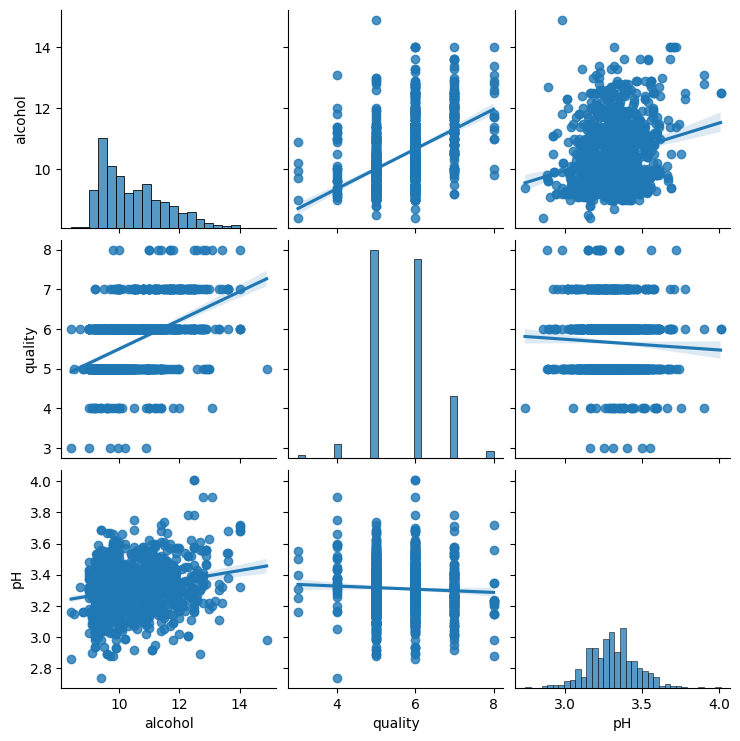

In [29]:
sns.pairplot(df,vars = ['alcohol', 'quality','pH'], kind="reg")
plt.show()

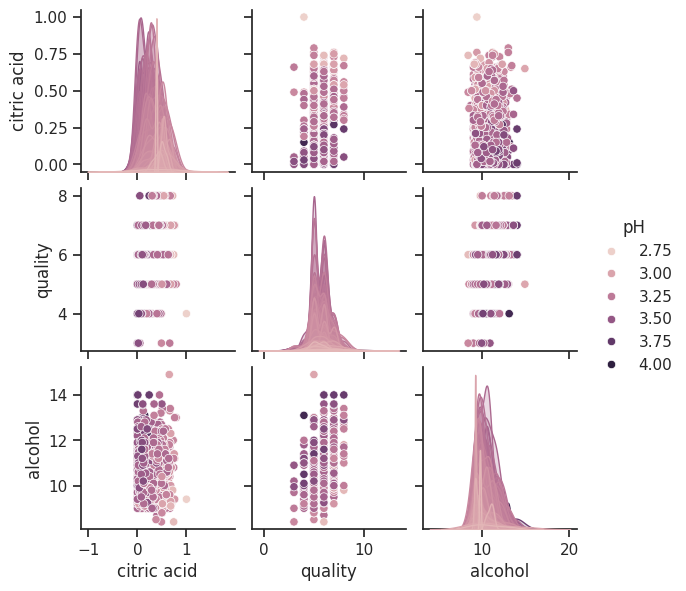

In [30]:
sns.set(style="ticks", color_codes=True)
sns.pairplot(df,height=2,vars = ['citric acid', 'quality','alcohol'], hue="pH")
plt.show()

In [31]:
corr = stats.pearsonr(df["pH"], df["alcohol"])
print("p-value:\t", corr[1])
print("cor:\t\t", corr[0])

p-value:	 1.2704383332771425e-14
cor:		 0.2253222028732469


In [32]:
correlation = df.corr(method='pearson', numeric_only=True)
correlation

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
fixed acidity,1.000000,-0.250728,0.673157,0.171831,0.107889,-0.164831,-0.110628,0.681501,-0.685163,0.174592,-0.075055,0.121970,-0.275826
volatile acidity,-0.250728,1.000000,-0.544187,-0.005751,0.056336,-0.001962,0.077748,0.016512,0.221492,-0.276079,-0.203909,-0.407394,-0.007892
citric acid,0.673157,-0.544187,1.000000,0.175815,0.245312,-0.057589,0.036871,0.375243,-0.546339,0.331232,0.106250,0.240821,-0.139011
residual sugar,0.171831,-0.005751,0.175815,1.000000,0.070863,0.165339,0.190790,0.380147,-0.116959,0.017475,0.058421,0.022002,-0.046344
chlorides,0.107889,0.056336,0.245312,0.070863,1.000000,0.015280,0.048163,0.208901,-0.277759,0.374784,-0.229917,-0.124085,-0.088099
free sulfur dioxide,-0.164831,-0.001962,-0.057589,0.165339,0.015280,1.000000,0.661093,-0.054150,0.072804,0.034445,-0.047095,-0.063260,0.095268
total sulfur dioxide,-0.110628,0.077748,0.036871,0.190790,0.048163,0.661093,1.000000,0.050175,-0.059126,0.026894,-0.188165,-0.183339,-0.107389
density,0.681501,0.016512,0.375243,0.380147,0.208901,-0.054150,0.050175,1.000000,-0.352775,0.143139,-0.494727,-0.175208,-0.363926
pH,-0.685163,0.221492,-0.546339,-0.116959,-0.277759,0.072804,-0.059126,-0.352775,1.000000,-0.185499,0.225322,-0.052453,0.132904
sulphates,0.174592,-0.276079,0.331232,0.017475,0.374784,0.034445,0.026894,0.143139,-0.185499,1.000000,0.094421,0.257710,-0.103954


<Axes: >

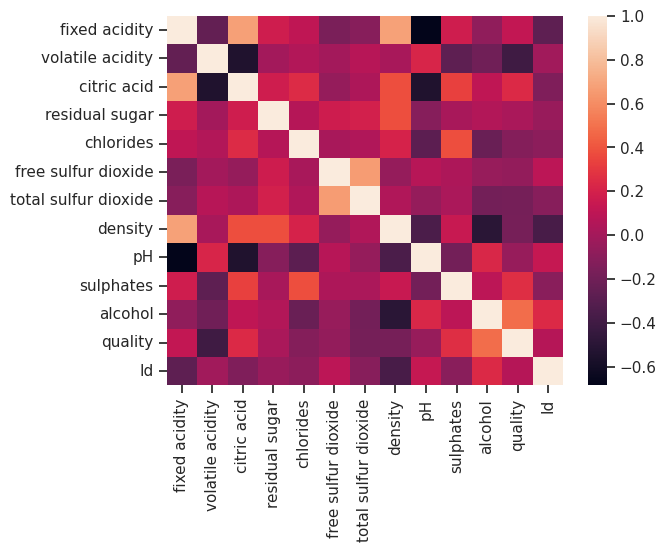

In [33]:
sns.heatmap(correlation,xticklabels=correlation.columns,
 yticklabels=correlation.columns)